# Linear Regression


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Nonlinear (多向式迴歸)

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [3]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x) + 0.8*x + 0.3*np.random.randn(100)  #用sin生成有幅度的資料，不是直直的線


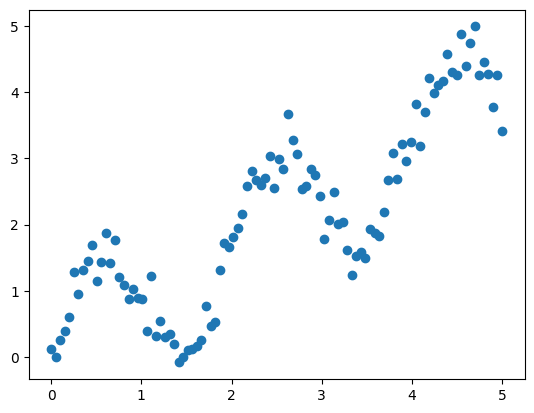

In [4]:
plt.scatter(x,y)

#### nonlinear

In [5]:
regr_lin = LinearRegression()

In [6]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [7]:
regr_lin.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


0.5861143872866399


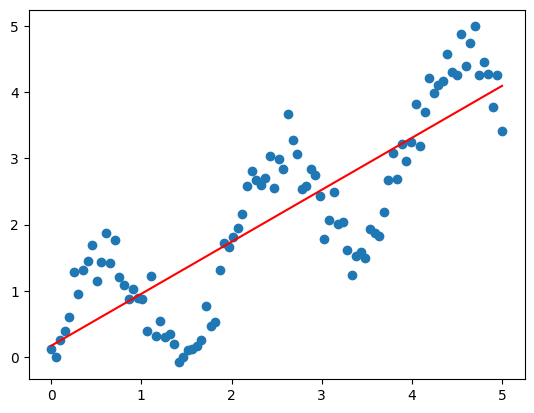

In [8]:
Y=regr_lin.predict(X)
plt.scatter(x,y)
plt.plot(x,Y , color='r')
mse = np.sum((Y-y)**2) / len(y)
print(mse)

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [9]:
print(x.shape)

(100,)


In [12]:
X_poly = np.array([[k, k**2, k**3, k**4, k**5] for k in x])  # add k**6 to try it
#X_poly   #100筆資料，每一筆5個維度
print(X_poly.shape)

(100, 5)


In [13]:
regr_poly = LinearRegression()

In [14]:
regr_poly.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


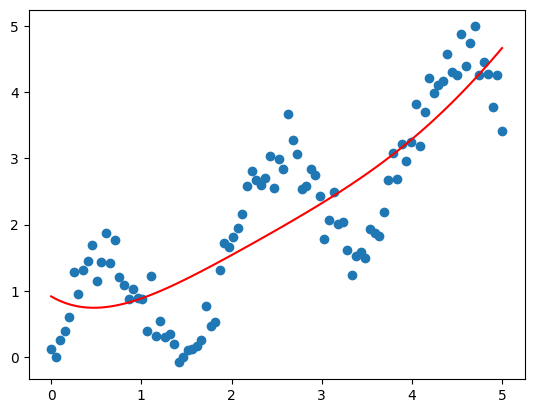

In [15]:
plt.scatter(x,y)
plt.plot(x, regr_poly.predict(X_poly), 'r')

In [16]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-0.79888772  1.08225841 -0.37284258  0.06193717 -0.00365376]
interception:  0.9171353598669076


In [ ]:
#方法一：自己手動算
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly,W.T)+b  #矩陣相乘 (X_poly或W都可以做轉置，目前範例使用W做轉置)

array([0.91713536, 0.87950045, 0.84710411, 0.81967249, 0.7969411 ,
       0.7786547 , 0.76456715, 0.75444125, 0.74804861, 0.74516952,
       0.74559276, 0.7491155 , 0.75554315, 0.76468919, 0.77637506,
       0.79042998, 0.80669084, 0.82500203, 0.84521531, 0.86718966,
       0.89079115, 0.91589277, 0.94237431, 0.97012219, 0.99902936,
       1.02899511, 1.05992493, 1.0917304 , 1.12432903, 1.1576441 ,
       1.19160453, 1.22614472, 1.26120445, 1.29672869, 1.33266745,
       1.36897569, 1.40561312, 1.4425441 , 1.47973746, 1.51716636,
       1.55480819, 1.59264437, 1.63066022, 1.66884485, 1.70719097,
       1.74569478, 1.78435579, 1.82317673, 1.86216335, 1.90132431,
       1.94067102, 1.98021751, 2.01998028, 2.05997813, 2.10023208,
       2.14076514, 2.18160225, 2.22277007, 2.26429688, 2.30621242,
       2.34854773, 2.39133503, 2.43460758, 2.47839949, 2.52274565,
       2.56768151, 2.613243  , 2.65946632, 2.70638787, 2.75404405,
       2.80247113, 2.85170513, 2.90178163, 2.95273567, 3.00460

In [21]:
#方法二：用函式算，結果同上
Y_train = regr_poly.predict(X_poly)
#Y_train
#手動算出MSE  mse = np.sum((Y_train-y_train)**2) / len(y_train)
mse = np.sum((Y_train-y)**2) / len(y)
mse

np.float64(0.5251689364585781)

#### RBF  (做常態分佈)

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [22]:
# normal distrubution
def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [23]:
sigma = 0.3

In [25]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])
X_rbf

array([[2.49352209e-01, 3.72665317e-06, 8.32396968e-16, 2.77873902e-30,
        1.38634329e-49],
       [3.25472872e-01, 8.52574586e-06, 3.33776477e-15, 1.95292168e-29,
        1.70773187e-48],
       [4.12959721e-01, 1.89599467e-05, 1.30098499e-14, 1.33417628e-28,
        2.04484269e-47],
       [5.09321387e-01, 4.09857759e-05, 4.92924229e-14, 8.85998378e-28,
        2.38007940e-46],
       [6.10614979e-01, 8.61232743e-05, 1.81542941e-13, 5.71931425e-27,
        2.69286330e-45],
       [7.11597342e-01, 1.75913523e-04, 6.49934950e-13, 3.58877569e-26,
        2.96161426e-44],
       [8.06106646e-01, 3.49276399e-04, 2.26178717e-12, 2.18897091e-25,
        3.16616832e-43],
       [8.87650512e-01, 6.74109702e-04, 7.65111808e-12, 1.29785145e-24,
        3.29026462e-42],
       [9.50129573e-01, 1.26468753e-03, 2.51587693e-11, 7.47999499e-24,
        3.32367827e-41],
       [9.88587205e-01, 2.30636063e-03, 8.04165068e-11, 4.19052994e-23,
        3.26361145e-40],
       [9.99858301e-01, 4.0884

In [26]:
regr_rbf = LinearRegression()

In [27]:
regr_rbf.fit(X_rbf, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


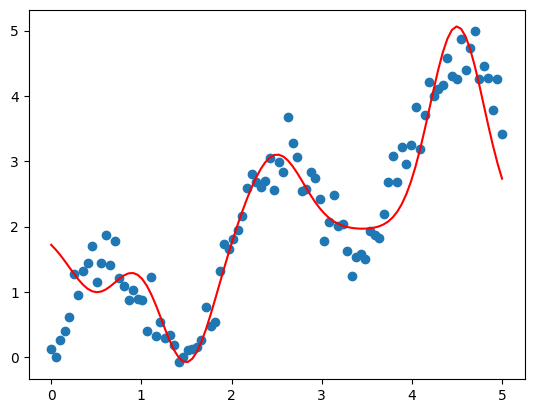

In [ ]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')
#經過常態分佈調整後，再做預測的線更fit數字

In [29]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-0.95563019 -2.03700217  1.15142154 -0.00602742  3.10494811]
interception:  1.958778574749347


#### Comparison

In [ ]:
#把上述的三個方法做一個比較(x不同)
Y_lin = regr_lin.predict(X)
Y_poly = regr_poly.predict(X_poly)
Y_rbf = regr_rbf.predict(X_rbf)

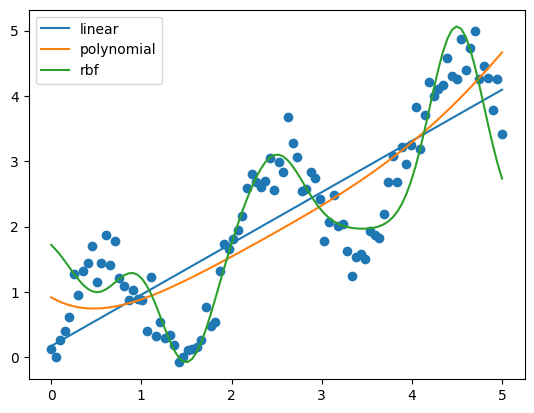

In [31]:
plt.scatter(x,y)

plt.plot(x, Y_lin, label='linear')
plt.plot(x, Y_poly, label='polynomial')
plt.plot(x, Y_rbf, label='rbf')
plt.legend()

## 請計算模型的MSE

In [32]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.5861143872866399


In [33]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.5251689364585781


In [34]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.2512314632385822


In [ ]:
#算出來的三種處理方式的MSE結果，使用rbf處理的最貼近結果
#如果預測結果不好，時可以試試換公式或方法預測看看